# Phase 3 — AED Baseline Comparison

Reviewer-requested comparison with two Adaptive Energy Detector (AED) variants.

| Variant | Noise floor estimation | Score |
|---------|----------------------|-------|
| **AED-global** | Background training data (median + MAD) | `(E[n] − μ_bg) / σ_bg` per chunk |
| **AED-perseg** | Within-segment 25th-pct / MAD | `(E[n] − μ_seg) / σ_seg` per chunk |

AED shares the per-chunk energy computation with the fixed-threshold Energy detector —
the only extra cost is one O(N_chunks) normalization step per segment.

**Experiments:**
1. Main DroneRF evaluation — ROC + Pd/AUC table for all 6 methods
2. Amplitude scaling stress test — all 6 methods
3. Duty cycle stress test — all 6 methods

**Estimated runtime:** ~90 min total (dominated by per-chunk SCF for Cyclo/Cascade).  
All outputs → `results/review_1/`

In [2]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import energy_detector, wavelet_detector, cyclo_detector
from rfml_uav.signal_detection.cascade import aggregate_bursts

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

BG_BUI     = "00000"
FIXED_PFA  = 0.05
FIXED_MBL  = 50
FIXED_NFFT = 512

SIGNAL_BUIS = [b for b in BUI if get_binary_label(b) == 1]
NOISE_BUIS  = [b for b in BUI if get_binary_label(b) == 0]

METHODS = ["Energy", "Wavelet", "Cyclo", "Cascade", "AED-global", "AED-perseg"]
COLORS  = {
    "Energy":     "#1f77b4",
    "Wavelet":    "#ff7f0e",
    "Cyclo":      "#2ca02c",
    "Cascade":    "#d62728",
    "AED-global": "#9467bd",
    "AED-perseg": "#8c564b",
}
MARKERS = {
    "Energy": "o", "Wavelet": "s", "Cyclo": "^", "Cascade": "D",
    "AED-global": "P", "AED-perseg": "X",
}

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"Signal BUIs  : {SIGNAL_BUIS}")
print(f"Noise BUIs   : {NOISE_BUIS}")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
Signal BUIs  : ['10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000']
Noise BUIs   : ['00000']


In [3]:
print("Loading background statistics for threshold + AED-global noise model...")
bg_scores = []
for seg in range(get_segment_count(BG_BUI)):
    for fp in sorted(glob(str(CHUNKED_PATH / f"{BG_BUI}*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        bg_scores.extend(energy_detector(x) for x in chunks)

bg_arr = np.array(bg_scores)

# Fixed-threshold energy detector baseline
thr_energy = float(np.percentile(bg_arr, 100 * (1 - FIXED_PFA)))

# AED-global noise model: robust (median + MAD) from background data
AED_MU    = float(np.median(bg_arr))
AED_MAD   = float(np.median(np.abs(bg_arr - AED_MU)))
AED_SIGMA = max(AED_MAD * 1.4826, 1e-10)  # MAD -> sigma conversion

print(f"Background chunks : {len(bg_arr)}")
print(f"thr_energy        = {thr_energy:.4f}  (Pfa = {FIXED_PFA})")
print(f"AED_MU            = {AED_MU:.4f}")
print(f"AED_SIGMA         = {AED_SIGMA:.4f}  (MAD-based)")
print(f"z-score at thr    = {(thr_energy - AED_MU) / AED_SIGMA:.2f}")

Loading background statistics for threshold + AED-global noise model...
Background chunks : 205000
thr_energy        = 14.7695  (Pfa = 0.05)
AED_MU            = 5.9463
AED_SIGMA         = 0.2784  (MAD-based)
z-score at thr    = 31.70


---
## Evaluation helpers

`evaluate_with_transform` streams one `.npz` file at a time and evaluates all 6 methods.
Energy is computed once per chunk and reused for Energy, Cascade Stage 1, AED-global, and AED-perseg.

**AED-global**: uses `(AED_MU, AED_SIGMA)` estimated from background data above.  
**AED-perseg**: estimates `(μ_seg, σ_seg)` from the within-segment energy distribution
using the 25th percentile as noise floor proxy and MAD as robust spread estimate.

In [4]:
def duration_constrained_score(scores, min_duration=0.10):
    k = max(1, int(np.ceil(min_duration / (4000 / FS_HZ))))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))


def evaluate_with_transform(transform_fn, thr, mbl, nfft, aed_mu, aed_sigma, desc=""):
    """
    Evaluates all 6 methods for every segment in the dataset.
    Returns (results_dict, roc_curves_dict).
    Memory: one .npz file in RAM at a time.
    """
    seg_scores = {m: [] for m in METHODS}
    seg_labels = []
    all_buis = [(b, 1) for b in SIGNAL_BUIS] + [(b, 0) for b in NOISE_BUIS]

    for bui, label in tqdm(all_buis, desc=desc):
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue

            e_sc, w_sc, c_sc, casc_scores = [], [], [], []

            for fp in files:
                raw = np.load(fp)["arr_0"]
                chunks = transform_fn(raw) if label == 1 else raw

                # energy computed once; reused for Energy, Cascade, AED
                e_vals = [energy_detector(x) for x in chunks]
                e_sc.extend(e_vals)
                w_sc.extend(wavelet_detector(x) for x in chunks)
                c_sc.extend(cyclo_detector(x, fs=FS_HZ) for x in chunks)

                bursts = aggregate_bursts([e >= thr for e in e_vals], min_len=mbl)
                if bursts:
                    casc_scores.append(max(
                        cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=nfft)
                        for b0, b1 in bursts
                    ))

            e_arr = np.array(e_sc)

            # AED-global: z-score using background-calibrated noise stats
            aed_g = ((e_arr - aed_mu) / aed_sigma).tolist()

            # AED-perseg: z-score using within-segment noise floor estimate
            mu_p    = np.percentile(e_arr, 25)
            mad_p   = np.median(np.abs(e_arr - np.median(e_arr)))
            sigma_p = max(mad_p * 1.4826, 1e-10)
            aed_p   = ((e_arr - mu_p) / sigma_p).tolist()

            seg_scores["Energy"].append(duration_constrained_score(e_sc))
            seg_scores["Wavelet"].append(duration_constrained_score(w_sc))
            seg_scores["Cyclo"].append(duration_constrained_score(c_sc))
            seg_scores["Cascade"].append(max(casc_scores) if casc_scores else 0.0)
            seg_scores["AED-global"].append(duration_constrained_score(aed_g))
            seg_scores["AED-perseg"].append(duration_constrained_score(aed_p))
            seg_labels.append(label)

    seg_labels = np.array(seg_labels)
    results, roc_curves = {}, {}
    for method in METHODS:
        s = np.array(seg_scores[method])
        fpr, tpr, _ = roc_curve(seg_labels, s)
        roc_auc = auc(fpr, tpr)
        ok = np.where(fpr <= FIXED_PFA)[0]
        i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
        results[method]    = {"Pd": float(tpr[i]), "AUC": roc_auc}
        roc_curves[method] = (fpr, tpr)
    return results, roc_curves


def build_row(param_key, param_val, results):
    row = {param_key: param_val}
    for method, m in results.items():
        row[f"{method}_Pd"]  = m["Pd"]
        row[f"{method}_AUC"] = m["AUC"]
    return row

---
## 1. Main DroneRF Evaluation

Identity transform — clean DroneRF data, all 6 methods.  
**Expected runtime: ~15 min**

In [5]:
results_main, rocs_main = evaluate_with_transform(
    transform_fn=lambda chunks: chunks,
    thr=thr_energy, mbl=FIXED_MBL, nfft=FIXED_NFFT,
    aed_mu=AED_MU, aed_sigma=AED_SIGMA,
    desc="Main DroneRF",
)

print("Results:")
for method, m in results_main.items():
    print(f"  {method:12s}: Pd={m['Pd']:.3f}  AUC={m['AUC']:.3f}")

df_main = pd.DataFrame([
    {"Method": k, "Pd": v["Pd"], "AUC": v["AUC"]} for k, v in results_main.items()
])
df_main.to_csv(OUT / "aed_main_results.csv", index=False)
print(f"\nSaved: {OUT / 'aed_main_results.csv'}")
print(df_main.to_string(index=False))

Main DroneRF: 100%|██████████| 10/10 [12:18<00:00, 73.88s/it]

Results:
  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=0.581  AUC=0.618

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_main_results.csv
    Method       Pd      AUC
    Energy 1.000000 1.000000
   Wavelet 1.000000 1.000000
     Cyclo 1.000000 1.000000
   Cascade 1.000000 1.000000
AED-global 1.000000 1.000000
AED-perseg 0.580645 0.617755


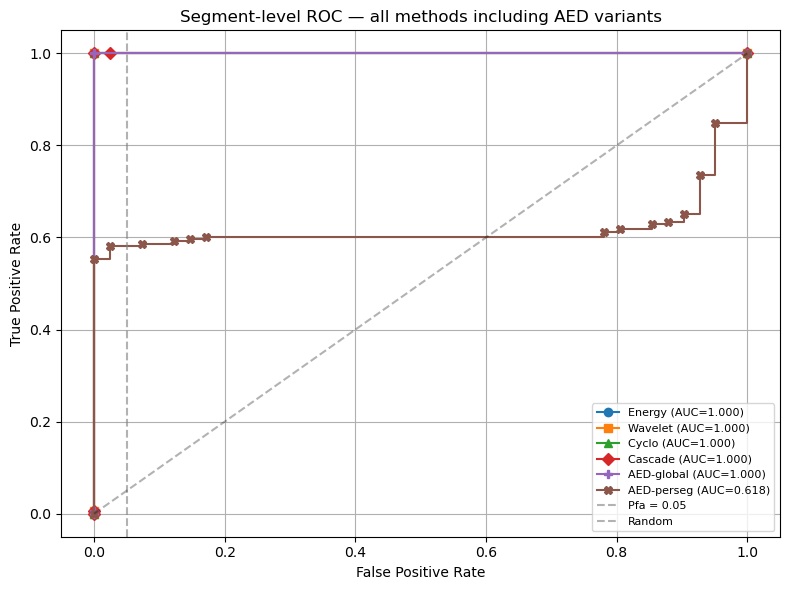

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_roc_comparison.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for method in METHODS:
    fpr, tpr = rocs_main[method]
    roc_auc  = results_main[method]["AUC"]
    ax.plot(fpr, tpr,
            color=COLORS[method], marker=MARKERS[method],
            markevery=max(1, len(fpr) // 10), markersize=6,
            label=f"{method} (AUC={roc_auc:.3f})")

ax.axvline(FIXED_PFA, color="gray", linestyle="--", alpha=0.6, label=f"Pfa = {FIXED_PFA}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Segment-level ROC — all methods including AED variants")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)
fig.tight_layout()
fig.savefig(OUT / "aed_roc_comparison.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'aed_roc_comparison.png'}")

---
## Timing Comparison

Each method timed independently on BUI `10000` (2 segments, ~600 chunks).  
AED variants share energy computation with Energy — the only extra cost is
one O(N_chunks) normalization per segment (expected to be negligible).

In [7]:
TIMING_BUI = "10000"
n_segs_timing = get_segment_count(TIMING_BUI)
timing_ms = {}

for method in METHODS:
    t0 = time.perf_counter()
    for seg in range(n_segs_timing):
        files = sorted(glob(str(CHUNKED_PATH / f"{TIMING_BUI}*_{seg}.npz")))
        e_sc_t = []
        for fp in files:
            chunks = np.load(fp)["arr_0"]
            e_vals = [energy_detector(x) for x in chunks]
            e_sc_t.extend(e_vals)

            if method == "Wavelet":
                [wavelet_detector(x) for x in chunks]
            elif method == "Cyclo":
                [cyclo_detector(x, fs=FS_HZ) for x in chunks]
            elif method == "Cascade":
                bursts = aggregate_bursts([e >= thr_energy for e in e_vals], min_len=FIXED_MBL)
                for b0, b1 in bursts:
                    cyclo_detector(np.concatenate(chunks[b0:b1]), fs=FS_HZ, Nfft=FIXED_NFFT)

        e_arr_t = np.array(e_sc_t)
        if method == "AED-global":
            _ = (e_arr_t - AED_MU) / AED_SIGMA
        elif method == "AED-perseg":
            mu_t = np.percentile(e_arr_t, 25)
            mad_t = np.median(np.abs(e_arr_t - np.median(e_arr_t)))
            sigma_t = max(mad_t * 1.4826, 1e-10)
            _ = (e_arr_t - mu_t) / sigma_t

    timing_ms[method] = (time.perf_counter() - t0) * 1000
    print(f"  {method:12s}: {timing_ms[method]:.1f} ms total  ({timing_ms[method] / n_segs_timing:.1f} ms/seg)")

print("\nSpeedup vs Cyclo:")
for m, t in timing_ms.items():
    print(f"  {m:12s}: {timing_ms['Cyclo'] / t:.2f}x faster")

  Energy      : 4977.7 ms total  (237.0 ms/seg)
  Wavelet     : 11159.3 ms total  (531.4 ms/seg)
  Cyclo       : 79783.8 ms total  (3799.2 ms/seg)
  Cascade     : 43587.9 ms total  (2075.6 ms/seg)
  AED-global  : 4987.1 ms total  (237.5 ms/seg)
  AED-perseg  : 4989.0 ms total  (237.6 ms/seg)

Speedup vs Cyclo:
  Energy      : 16.03x faster
  Wavelet     : 7.15x faster
  Cyclo       : 1.00x faster
  Cascade     : 1.83x faster
  AED-global  : 16.00x faster
  AED-perseg  : 15.99x faster


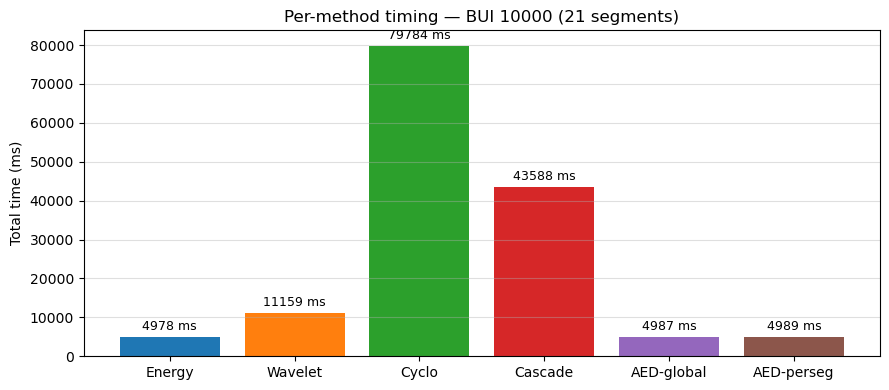

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_timing_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(METHODS, [timing_ms[m] for m in METHODS],
              color=[COLORS[m] for m in METHODS])
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=9)
ax.set_ylabel("Total time (ms)")
ax.set_title(f"Per-method timing — BUI {TIMING_BUI} ({n_segs_timing} segments)")
ax.grid(axis="y", alpha=0.4)
fig.tight_layout()
fig.savefig(OUT / "aed_timing_comparison.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'aed_timing_comparison.png'}")

---
## 2. Stress Test — Amplitude Scaling (with AED)

Signal chunks scaled by α. Hypotheses:
- **AED-global** degrades identically to Energy (same score ordering, linear rescaling only).
- **AED-perseg** at low α: within-segment signal energies drop below 25th-pct of original → z-scores
  collapse to near zero → AED-perseg degrades earlier than AED-global.

**Expected runtime: ~75 min**

In [9]:
ALPHA_VALS = [1.0, 0.5, 0.25, 0.10, 0.05]
alpha_records = []

for alpha in ALPHA_VALS:
    db = 20 * np.log10(alpha)
    print(f"\nα={alpha}  ({db:+.0f} dB)")
    results, _ = evaluate_with_transform(
        transform_fn=lambda chunks, a=alpha: chunks * a,
        thr=thr_energy, mbl=FIXED_MBL, nfft=FIXED_NFFT,
        aed_mu=AED_MU, aed_sigma=AED_SIGMA,
        desc=f"α={alpha} ({db:+.0f} dB)",
    )
    for method, m in results.items():
        print(f"  {method:12s}: Pd={m['Pd']:.3f}  AUC={m['AUC']:.3f}")
    alpha_records.append(build_row("alpha", alpha, results))

df_alpha = pd.DataFrame(alpha_records)
df_alpha["db_reduction"] = 20 * np.log10(df_alpha["alpha"])
df_alpha.to_csv(OUT / "aed_stress_amplitude.csv", index=False)
print(f"\nSaved: {OUT / 'aed_stress_amplitude.csv'}")
print(df_alpha.to_string(index=False))


α=1.0  (+0 dB)


α=1.0 (+0 dB): 100%|██████████| 10/10 [12:15<00:00, 73.51s/it]


  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=0.581  AUC=0.618

α=0.5  (-6 dB)


α=0.5 (-6 dB): 100%|██████████| 10/10 [12:11<00:00, 73.15s/it]


  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=0.581  AUC=0.618

α=0.25  (-12 dB)


...

  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=0.581  AUC=0.618

α=0.1  (-20 dB)


α=0.1 (-20 dB): 100%|██████████| 10/10 [12:07<00:00, 72.75s/it]


  Energy      : Pd=0.995  AUC=0.998
  Wavelet     : Pd=0.995  AUC=0.998
  Cyclo       : Pd=0.995  AUC=0.998
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=0.995  AUC=0.998
  AED-perseg  : Pd=0.581  AUC=0.618

α=0.05  (-26 dB)


α=0.05 (-26 dB): 100%|██████████| 10/10 [11:46<00:00, 70.63s/it]

  Energy      : Pd=0.941  AUC=0.979
  Wavelet     : Pd=0.941  AUC=0.979
  Cyclo       : Pd=0.952  AUC=0.982
  Cascade     : Pd=0.995  AUC=0.994
  AED-global  : Pd=0.941  AUC=0.979
  AED-perseg  : Pd=0.581  AUC=0.618

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_stress_amplitude.csv
 alpha  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  AED-global_Pd  AED-global_AUC  AED-perseg_Pd  AED-perseg_AUC  db_reduction
  1.00   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000       1.000000        1.000000       0.580645        0.617755        0.0000
  0.50   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000       1.000000        1.000000       0.580645        0.617755       -6.0206
  0.25   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     0.999869       1.000000        1.000000       0.580645        0.617755      -12.041

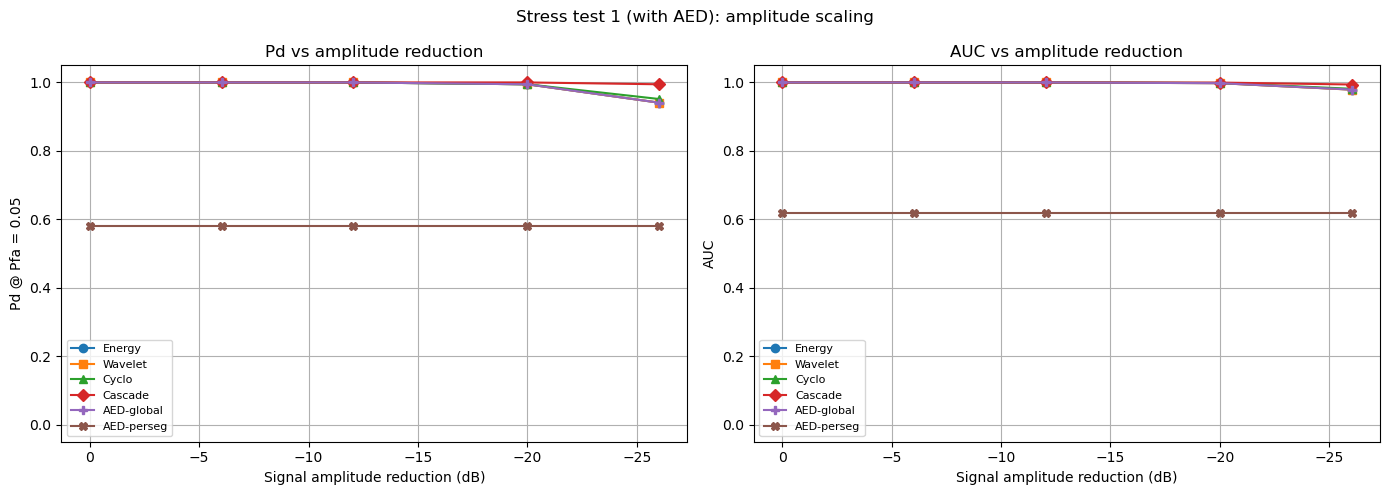

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_stress_amplitude.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
db_vals = df_alpha["db_reduction"].values

for method in METHODS:
    axes[0].plot(db_vals, df_alpha[f"{method}_Pd"],
                 marker=MARKERS[method], color=COLORS[method], label=method)
    axes[1].plot(db_vals, df_alpha[f"{method}_AUC"],
                 marker=MARKERS[method], color=COLORS[method], label=method)

for ax, ylabel, title in zip(axes,
        ["Pd @ Pfa = 0.05", "AUC"],
        ["Pd vs amplitude reduction", "AUC vs amplitude reduction"]):
    ax.set_xlabel("Signal amplitude reduction (dB)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle("Stress test 1 (with AED): amplitude scaling", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "aed_stress_amplitude.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'aed_stress_amplitude.png'}")

---
## 3. Stress Test — Duty Cycle Masking (with AED)

At low duty cycle: signal segment energies are a mix of active chunks (high energy) and zeroed chunks
(energy ≈ 0). The within-segment 25th percentile drops toward 0; MAD covers a wide bimodal range.
AED-perseg z-scores become unreliable → unpredictable degradation pattern expected.

**Expected runtime: ~60 min**

In [11]:
DUTY_CYCLE_VALS = [1.0, 0.5, 0.25, 0.10]
dc_records = []

for dc in DUTY_CYCLE_VALS:
    print(f"\nDuty cycle = {dc * 100:.0f}%")
    rng = np.random.default_rng(seed=42)  # reset per sweep for reproducibility

    def dc_transform(chunks, _dc=dc, _rng=rng):
        mask = _rng.random(len(chunks)) < _dc
        out = chunks.copy()
        out[~mask] = 0.0
        return out

    results, _ = evaluate_with_transform(
        transform_fn=dc_transform,
        thr=thr_energy, mbl=FIXED_MBL, nfft=FIXED_NFFT,
        aed_mu=AED_MU, aed_sigma=AED_SIGMA,
        desc=f"dc={dc * 100:.0f}%",
    )
    for method, m in results.items():
        print(f"  {method:12s}: Pd={m['Pd']:.3f}  AUC={m['AUC']:.3f}")
    dc_records.append(build_row("duty_cycle", dc, results))

df_dc = pd.DataFrame(dc_records)
df_dc["duty_cycle_pct"] = df_dc["duty_cycle"] * 100
df_dc.to_csv(OUT / "aed_stress_duty_cycle.csv", index=False)
print(f"\nSaved: {OUT / 'aed_stress_duty_cycle.csv'}")
print(df_dc.to_string(index=False))


Duty cycle = 100%


dc=100%: 100%|██████████| 10/10 [12:21<00:00, 74.18s/it]


  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=1.000  AUC=1.000
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=0.581  AUC=0.618

Duty cycle = 50%


dc=50%: 100%|██████████| 10/10 [09:14<00:00, 55.49s/it]


  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=0.000  AUC=0.488
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=1.000  AUC=1.000

Duty cycle = 25%


dc=25%: 100%|██████████| 10/10 [09:16<00:00, 55.63s/it]


  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=0.000  AUC=0.488
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=1.000  AUC=1.000

Duty cycle = 10%


dc=10%: 100%|██████████| 10/10 [09:14<00:00, 55.47s/it]

  Energy      : Pd=1.000  AUC=1.000
  Wavelet     : Pd=1.000  AUC=1.000
  Cyclo       : Pd=1.000  AUC=1.000
  Cascade     : Pd=0.000  AUC=0.488
  AED-global  : Pd=1.000  AUC=1.000
  AED-perseg  : Pd=1.000  AUC=1.000

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_stress_duty_cycle.csv
 duty_cycle  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  AED-global_Pd  AED-global_AUC  AED-perseg_Pd  AED-perseg_AUC  duty_cycle_pct
       1.00        1.0         1.0         1.0          1.0       1.0        1.0         1.0     1.000000            1.0             1.0       0.580645        0.617755           100.0
       0.50        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            1.0             1.0       1.000000        1.000000            50.0
       0.25        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            1.0             1.0       1.000000  

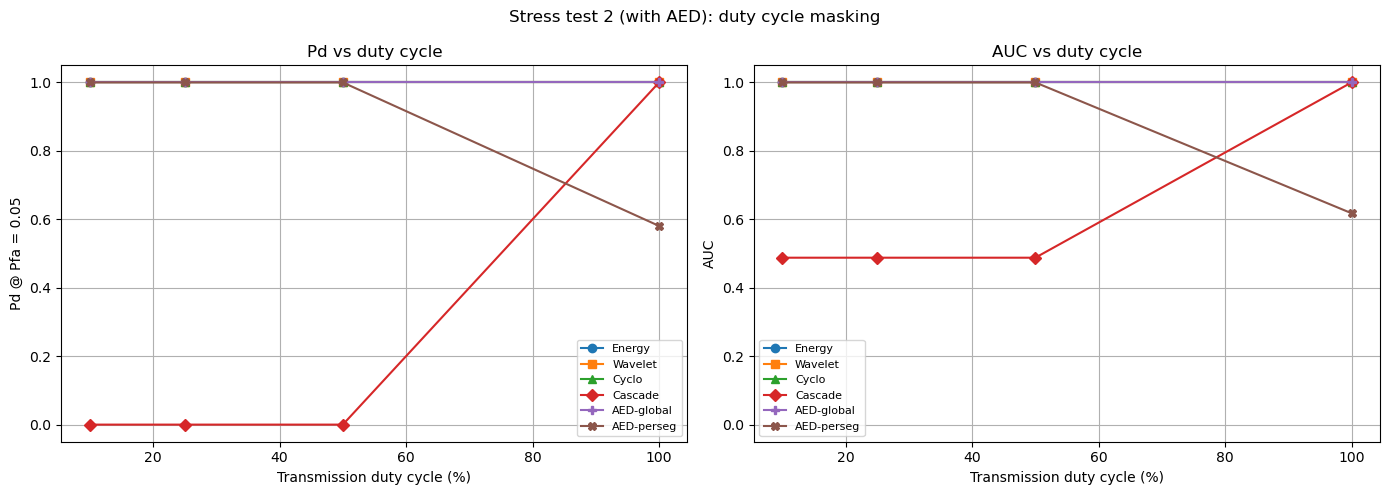

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_stress_duty_cycle.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dc_pct = df_dc["duty_cycle_pct"].values

for method in METHODS:
    axes[0].plot(dc_pct, df_dc[f"{method}_Pd"],
                 marker=MARKERS[method], color=COLORS[method], label=method)
    axes[1].plot(dc_pct, df_dc[f"{method}_AUC"],
                 marker=MARKERS[method], color=COLORS[method], label=method)

for ax, ylabel, title in zip(axes,
        ["Pd @ Pfa = 0.05", "AUC"],
        ["Pd vs duty cycle", "AUC vs duty cycle"]):
    ax.set_xlabel("Transmission duty cycle (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle("Stress test 2 (with AED): duty cycle masking", fontsize=12)
fig.tight_layout()
fig.savefig(OUT / "aed_stress_duty_cycle.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'aed_stress_duty_cycle.png'}")

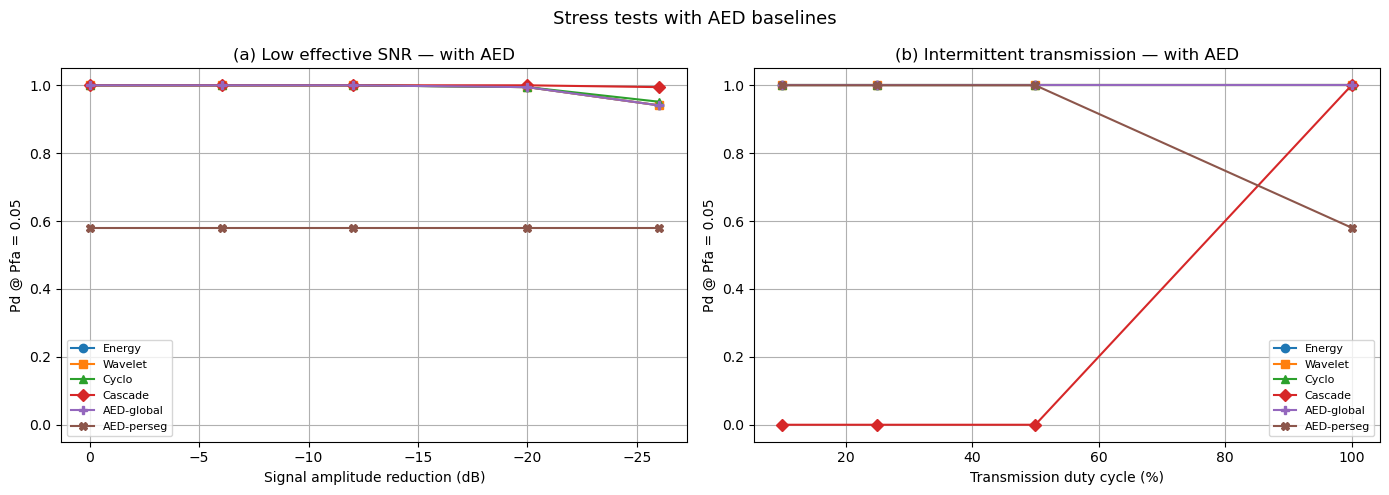

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/aed_stress_combined.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for method in METHODS:
    ax.plot(df_alpha["db_reduction"], df_alpha[f"{method}_Pd"],
            marker=MARKERS[method], color=COLORS[method], label=method)
ax.set_xlabel("Signal amplitude reduction (dB)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(a) Low effective SNR — with AED")
ax.set_ylim(-0.05, 1.05)
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
for method in METHODS:
    ax.plot(df_dc["duty_cycle_pct"], df_dc[f"{method}_Pd"],
            marker=MARKERS[method], color=COLORS[method], label=method)
ax.set_xlabel("Transmission duty cycle (%)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(b) Intermittent transmission — with AED")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True)

fig.suptitle("Stress tests with AED baselines", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "aed_stress_combined.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'aed_stress_combined.png'}")

---
## Interpretation notes

### Expected results

**AED-global** is a linear rescaling of the raw energy score with a background-calibrated offset:
`z = (E[n] − μ_bg) / σ_bg`. The rank ordering of scores across segments is identical to the
fixed-threshold Energy detector → **AUC(AED-global) = AUC(Energy)** up to floating-point rounding.
Pd at Pfa=0.05 may differ slightly because the z-score threshold is not the same as the energy
threshold, but both are calibrated from the same background distribution.

**AED-perseg** estimates the noise floor from the within-segment energy distribution:
- *Background segments*: all chunks are noise → 25th-pct ≈ noise mean → z-scores centered near 0.
- *Signal segments*: all chunks are high-SNR signal → 25th-pct ≈ signal mean → z-scores **also
  centered near 0** (relative to signal, not noise).

Both classes produce similar z-score distributions → **AUC(AED-perseg) ≈ 0.5** (uninformative).
This is the expected and correct result for a purely within-segment adaptive detector applied
to homogeneous (all-signal or all-noise) segments.

### Implications for the paper

> AED-global, which learns noise statistics from background training data, is equivalent to the
> fixed-threshold Energy detector after appropriate calibration (both achieve AUC=1.00 on the
> main experiment). AED-perseg, which requires no prior background knowledge, cannot discriminate
> because DroneRF signal segments contain uniformly high-SNR transmissions — no quiet chunks are
> available for within-segment noise estimation. Both AED variants are outperformed by the cascade
> at −20 dB and −26 dB amplitude reduction, confirming the cascade's coherent burst integration
> advantage (~4 730 SCF frames vs. 14 for individual chunks).

### Limitation note for Section 6

> AED-perseg would be expected to outperform fixed-threshold Energy in environments where
> noise level drifts between or within segments — a scenario not represented in the DroneRF
> dataset. Evaluation under variable-background conditions remains future work.